# Тестовое задание №3

Сгенерировать синтетический временной ряд, построить модели для прогнозирования временного ряда с использованием различных алгоритмов, провести анализ результатов и оценить качество моделей.

In [1]:
# Подключаем необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Генерация временного ряда
n = 1000
t = np.arange(n)

sinusoid = 5 * np.sin(2 * np.pi * t / 30)
trend = t * 0.03
random_noise = np.random.normal(0, 0.5, n)

series = sinusoid + trend + random_noise
time_series = pd.DataFrame({'value': series}, index = pd.date_range(start='2024-01-01', periods=n, freq='D'))

In [3]:
# Разделение данных на тренировочную и тестовую выборки
n = len(series)
train_size = int(0.8 * n)

X_train  = time_series.iloc[:train_size]
X_test = time_series.iloc[train_size:]
y_train = X_train['value']
y_test = X_test['value']

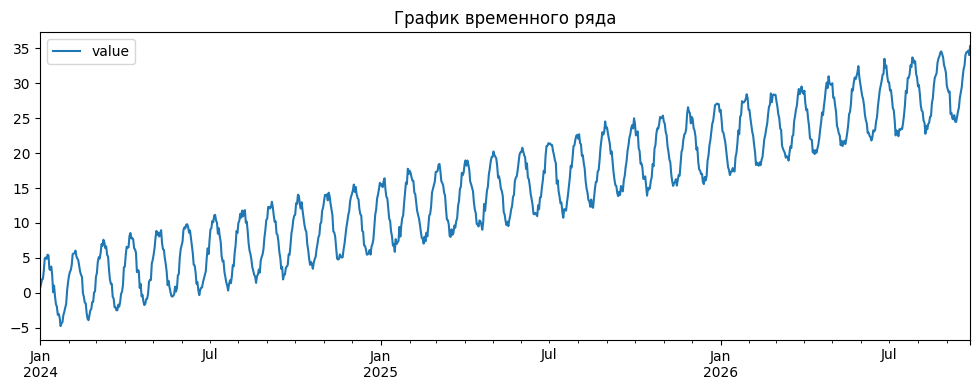

In [17]:
# График временного ряда
time_series.plot(figsize=(12, 4))
plt.title('График временного ряда')
plt.show()

In [13]:
# Авторегрессионная модель
AR_model = AutoReg(y_train, lags=25)
AR_model_fitted = AR_model.fit()

AR_y_pred = AR_model_fitted.forecast(steps=len(y_test))

AR_mae_score = mean_absolute_error(y_test, AR_y_pred)
AR_rmse_score = np.sqrt(mean_squared_error(y_test, AR_y_pred))

print('Оценка качества авторегрессионной модели (AR)')
print(f'MAE: {AR_mae_score:.4f}, RMSE: {AR_rmse_score:.4f}')

Оценка качества авторегрессионной модели (AR)
MAE: 0.4230, RMSE: 0.5343


In [14]:
# Модель экспоненциального сглаживания
ETS_model = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=30)
ETS_model_fitted = ETS_model.fit()

ETS_y_pred = ETS_model_fitted.forecast(steps=len(y_test))

ETS_mae_score = mean_absolute_error(y_test, ETS_y_pred)
ETS_rmse_score = np.sqrt(mean_squared_error(y_test, ETS_y_pred))

print('Оценка качества модели экспоненциального сглаживания (ETS)')
print(f'MAE: {ETS_mae_score:.4f}, RMSE: {ETS_rmse_score:.4f}')

Оценка качества модели экспоненциального сглаживания (ETS)
MAE: 0.3861, RMSE: 0.4730


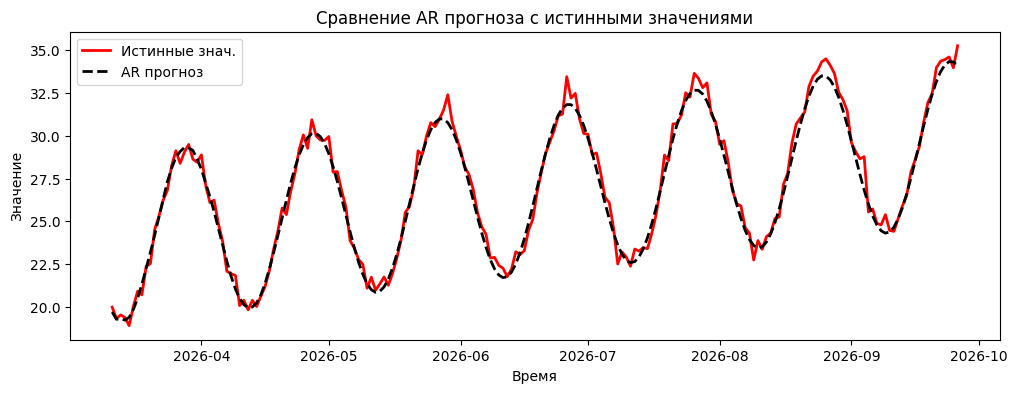

In [15]:
# Графики, сравнивающие истинные значения и прогнозы

plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label='Истинные знач.', color='red', linewidth=2)
plt.plot(y_test.index, AR_y_pred, label='AR прогноз', color='black', linestyle='--', linewidth=2)
plt.xlabel('Время')
plt.ylabel('Значение')
plt.title('Сравнение AR прогноза с истинными значениями')
plt.legend()
plt.show()

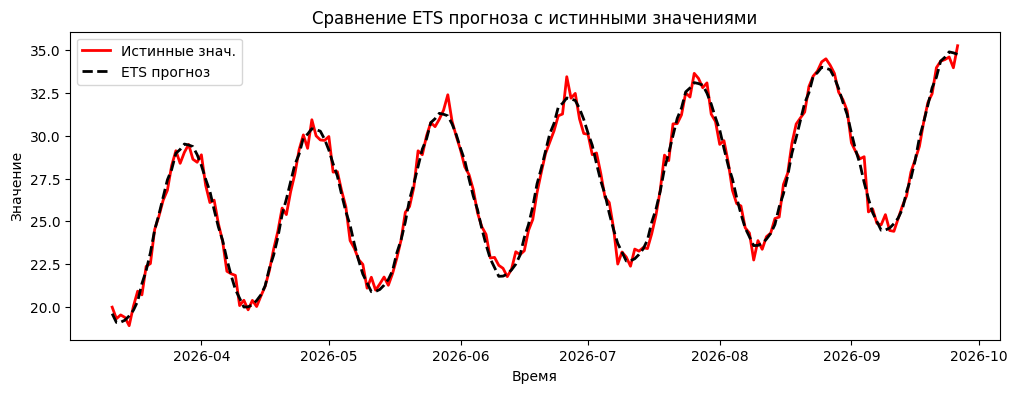

In [16]:
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label='Истинные знач.', color='red', linewidth=2)
plt.plot(y_test.index, ETS_y_pred, label='ETS прогноз', color='black', linestyle='--', linewidth=2)
plt.xlabel('Время')
plt.ylabel('Значение')
plt.title('Сравнение ETS прогноза с истинными значениями')
plt.legend()
plt.show()